# Hotel Booking Cancellation — v2 · Baseline: predict the cancellation rate

A `DummyClassifier(strategy='prior')` gives every booking the training cancellation rate.
Its AP equals the cancel rate of the fold, so it is the floor every real model must clear. At a 0.5
threshold it never predicts a cancellation, so its precision, recall and F1 are 0.

Every score below comes from nested cross-validation on the v2 training rows only, using the folds
saved in `data/processed/v2/cv_folds.csv`: for outer fold *k*, the settings are chosen on the three
saved inner folds (`inner_fold_k`) of the other rows, and the chosen model is scored once on fold *k*,
which it never saw. Encoders and scalers are refitted inside every fit. `test.csv` is not opened.

v1 scores are historical (different split) and are not compared with these.

In [1]:
import hashlib
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score
from sklearn.dummy import DummyClassifier

palette = ['#2B5C8F', '#E05A47']

## 1. Training rows and saved folds

In [2]:
train = pd.read_csv('../../data/processed/v2/train.csv', dtype={'agent': str})
folds = pd.read_csv('../../data/processed/v2/cv_folds.csv')

# the files must be the ones the v2 manifest froze; test.csv is never read here
manifest = json.load(open('../../data/processed/v2/manifest.json'))
for name in ['train.csv', 'cv_folds.csv']:
    digest = hashlib.sha256(Path('../../data/processed/v2', name).read_bytes()).hexdigest()
    assert digest == manifest['files'][name], f'{name} does not match the manifest'

assert (folds.row_id.to_numpy() == np.arange(len(train))).all()
X, y = train.drop(columns='is_canceled'), train['is_canceled'].to_numpy()
print('train:', X.shape, f' cancel rate {y.mean():.4f}')
folds.groupby('outer_fold').size().rename('rows').to_frame().T

train: (67974, 25)  cancel rate 0.2775


outer_fold,0,1,2,3,4
rows,13595,13594,13595,13595,13595


## 2. Nested evaluation

Nothing to tune, so each outer fold is a plain fit on the other four.

In [3]:
MODEL, SLUG = 'Dummy (prior)', 'dummy'

rows, oof = [], np.full(len(y), np.nan)

for k in range(5):
    fit_idx = np.flatnonzero(folds.outer_fold != k)
    val_idx = np.flatnonzero(folds.outer_fold == k)

    model = DummyClassifier(strategy='prior')
    start = time.perf_counter()
    model.fit(X.iloc[fit_idx], y[fit_idx])
    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    proba = model.predict_proba(X.iloc[val_idx])[:, 1]
    predict_seconds = time.perf_counter() - start
    oof[val_idx] = proba

    pred = proba >= 0.5
    rows.append({
        'model': MODEL, 'outer_fold': k,
        'ap': average_precision_score(y[val_idx], proba),
        'precision': precision_score(y[val_idx], pred, zero_division=0),
        'recall': recall_score(y[val_idx], pred),
        'f1': f1_score(y[val_idx], pred),
        'inner_ap': np.nan,
        'best_params': '{}',
        'search_seconds': fit_seconds,
        'refit_seconds': fit_seconds,
        'predict_seconds': predict_seconds,
        'n_fit': len(fit_idx), 'n_eval': len(val_idx),
    })

assert not np.isnan(oof).any()
per_fold = pd.DataFrame(rows)
per_fold.drop(columns='model').round(4)

,outer_fold,ap,precision,recall,f1,inner_ap,best_params,search_seconds,refit_seconds,predict_seconds,n_fit,n_eval
0,0,0.2775,0.0,0.0,0.0,NaN,{},0.0364,0.0364,0.0042,54379,13595
1,1,0.2775,0.0,0.0,0.0,NaN,{},0.0155,0.0155,0.0042,54380,13594
2,2,0.2775,0.0,0.0,0.0,NaN,{},0.0099,0.0099,0.0034,54379,13595
3,3,0.2775,0.0,0.0,0.0,NaN,{},0.0088,0.0088,0.0036,54379,13595
4,4,0.2775,0.0,0.0,0.0,NaN,{},0.0098,0.0098,0.0038,54379,13595


## Summary

Dummy (prior): AP 0.2775 +/- 0.0000 (SD over 5 outer folds, ddof=1)
pooled out-of-fold AP: 0.2775
cancelled class at 0.5: precision 0.0000, recall 0.0000, F1 0.0000


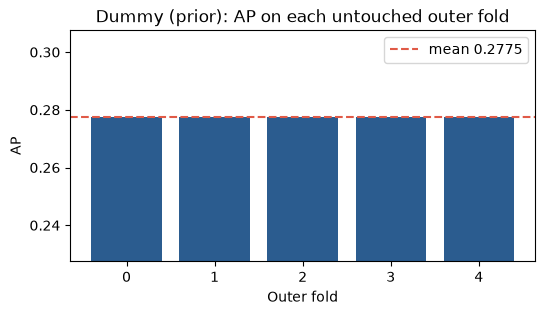

In [4]:
ap = per_fold['ap']
print(f'{MODEL}: AP {ap.mean():.4f} +/- {ap.std():.4f} (SD over 5 outer folds, ddof=1)')
print(f'pooled out-of-fold AP: {average_precision_score(y, oof):.4f}')
print('cancelled class at 0.5: precision {:.4f}, recall {:.4f}, F1 {:.4f}'.format(
    *per_fold[['precision', 'recall', 'f1']].mean()))

plt.figure(figsize=(6, 3))
plt.bar(per_fold['outer_fold'].astype(str), ap, color=palette[0])
plt.axhline(ap.mean(), color=palette[1], linestyle='--', label=f'mean {ap.mean():.4f}')
plt.ylim(max(0, ap.min() - 0.05), min(1, ap.max() + 0.03))
plt.xlabel('Outer fold')
plt.ylabel('AP')
plt.title(f'{MODEL}: AP on each untouched outer fold')
plt.legend()
plt.show()

## Save

`reports/results/v2/dummy.csv`: one row per outer fold, then the mean and SD rows. `reports/results/v2/oof/dummy.csv`: every training row's out-of-fold probability, aligned to `row_id`, for stages 9.4–9.6.

In [5]:
summary = per_fold.drop(columns=['outer_fold', 'best_params', 'model'])
out = pd.concat([
    per_fold.assign(outer_fold=per_fold['outer_fold'].astype(str)),
    summary.mean().to_frame().T.assign(model=MODEL, outer_fold='mean', best_params=''),
    summary.std().to_frame().T.assign(model=MODEL, outer_fold='sd', best_params=''),
], ignore_index=True)[per_fold.columns]

results = Path('../../reports/results/v2')
(results / 'oof').mkdir(parents=True, exist_ok=True)
out.to_csv(results / f'{SLUG}.csv', index=False)
pd.DataFrame({'row_id': folds.row_id, 'outer_fold': folds.outer_fold,
              'is_canceled': y, 'proba': oof}).to_csv(results / 'oof' / f'{SLUG}.csv', index=False)
out.round(4)

,model,outer_fold,ap,precision,recall,f1,inner_ap,best_params,search_seconds,refit_seconds,predict_seconds,n_fit,n_eval
0,Dummy (prior),0,0.2775,0.0,0.0,0.0,NaN,{},0.0364,0.0364,0.0042,54379.0000,13595.0000
1,Dummy (prior),1,0.2775,0.0,0.0,0.0,NaN,{},0.0155,0.0155,0.0042,54380.0000,13594.0000
2,Dummy (prior),2,0.2775,0.0,0.0,0.0,NaN,{},0.0099,0.0099,0.0034,54379.0000,13595.0000
3,Dummy (prior),3,0.2775,0.0,0.0,0.0,NaN,{},0.0088,0.0088,0.0036,54379.0000,13595.0000
4,Dummy (prior),4,0.2775,0.0,0.0,0.0,NaN,{},0.0098,0.0098,0.0038,54379.0000,13595.0000
5,Dummy (prior),mean,0.2775,0.0,0.0,0.0,NaN,,0.0161,0.0161,0.0038,54379.2000,13594.8000
6,Dummy (prior),sd,0.0000,0.0,0.0,0.0,NaN,,0.0117,0.0117,0.0004,0.4472,0.4472
